# Exploratory Data Analysis


## Install packages

In [35]:
import pandas as pd
import re
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from bs4 import BeautifulSoup
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

## Data Cleaning

In [36]:
df = pd.read_csv("data/DataSet.csv")
df.head()

,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent,in_balanced_dataset
0,Marketing Intern,"US, NY, New York",Marketing,NaN,"<h3>We're Food52, and we've created a groundbr...","<p>Food52, a fast-growing, James Beard Award-w...",<ul>\r\n<li>Experience with content management...,NaN,f,t,f,Other,Internship,NaN,NaN,Marketing,f,f
1,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"<h3>90 Seconds, the worlds Cloud Video Product...",<p>Organised - Focused - Vibrant - Awesome!<br...,<p><b>What we expect from you:</b></p>\r\n<p>Y...,<h3><b>What you will get from us</b></h3>\r\n<...,f,t,f,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,f,f
2,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,<h3></h3>\r\n<p>Valor Services provides Workfo...,"<p>Our client, located in Houston, is actively...",<ul>\r\n<li>Implement pre-commissioning and co...,NaN,f,t,f,NaN,NaN,NaN,NaN,NaN,f,f
3,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,<p>Our passion for improving quality of life t...,<p><b>THE COMPANY: ESRI – Environmental System...,<ul>\r\n<li>\r\n<b>EDUCATION: </b>Bachelor’s o...,<p>Our culture is anything but corporate—we ha...,f,t,f,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,f,f
4,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,<p>SpotSource Solutions LLC is a Global Human ...,<p><b>JOB TITLE:</b> Itemization Review Manage...,<p><b>QUALIFICATIONS:</b></p>\r\n<ul>\r\n<li>R...,<p>Full Benefits Offered</p>,f,t,t,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,f,f


In [37]:
# removing HTML tags to clean dataset
def clean_html(text):
    if pd.isna(text):
        return ""
    return BeautifulSoup(text, "html.parser").get_text()

text_cols = [
    "company_profile",
    "description",
    "requirements",
    "benefits"
]

for col in text_cols:
    df[col] = df[col].apply(clean_html)

/var/folders/q2/_kj_jvmd09d2vj26tyjy25nh0000gn/T/ipykernel_11280/96894343.py:5: MarkupResemblesLocatorWarning: The input looks more like a filename than markup. You may want to open this file and pass the filehandle into Beautiful Soup.
  return BeautifulSoup(text, "html.parser").get_text()


In [38]:
# check count of null values (sign of potential SCAMS)
df.info()
df.isnull().sum()

# replace null with empty strings for modelling later
df[text_cols] = df[text_cols].fillna("")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17880 entries, 0 to 17879
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   title                17880 non-null  object
 1   location             17534 non-null  object
 2   department           6333 non-null   object
 3   salary_range         2868 non-null   object
 4   company_profile      17880 non-null  object
 5   description          17880 non-null  object
 6   requirements         17880 non-null  object
 7   benefits             17880 non-null  object
 8   telecommuting        17880 non-null  object
 9   has_company_logo     17880 non-null  object
 10  has_questions        17880 non-null  object
 11  employment_type      14409 non-null  object
 12  required_experience  10830 non-null  object
 13  required_education   9775 non-null   object
 14  industry             12977 non-null  object
 15  function             11425 non-null  object
 16  frau

In [39]:
# set NA values of salary_range to "Unknown" -> sign of SCAMS?
df["salary_range"] = df["salary_range"].fillna("Unknown")

# convert telecommuting, has_company_logo, has_questions, fraudulent, in_balanced_dataset to booleans
bool_cols = [
    "telecommuting",
    "has_company_logo",
    "has_questions",
    "fraudulent",
    "in_balanced_dataset"
]

df[bool_cols] = df[bool_cols].replace({'t': True, 'f': False}).astype(bool)

/var/folders/q2/_kj_jvmd09d2vj26tyjy25nh0000gn/T/ipykernel_11280/1717996047.py:13: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[bool_cols] = df[bool_cols].replace({'t': True, 'f': False}).astype(bool)


In [40]:
# normalize text
def clean_text(text):
    text = text.lower()
    text = re.sub(r'\n', ' ', text)
    text = re.sub(r'[^a-zA-Z0-9 ]', '', text)
    return text

for col in text_cols:
    df[col] = df[col].apply(clean_text)

In [32]:
# feature engineering to identify potential SCAMS
df["description_length"] = df["description"].apply(len)
df["requirements_length"] = df["requirements"].apply(len)
df["company_profile_length"] = df["company_profile"].apply(len)
df["missing_fields"] = df.isnull().sum(axis=1)

In [33]:
# Count of fraudulent vs non-fraudulent
fraud_counts = df['fraudulent'].value_counts()
print(fraud_counts)

# Optional: percentage
fraud_percentage = df['fraudulent'].value_counts(normalize=True) * 100
print(fraud_percentage)

fraudulent
False    17014
True       866
Name: count, dtype: int64
fraudulent
False    95.1566
True      4.8434
Name: proportion, dtype: float64


In [34]:
# check for duplicate job postings -> potential antisigns of SCAMS
df.duplicated().sum()
df[df.duplicated()]

,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,...,required_experience,required_education,industry,function,fraudulent,in_balanced_dataset,description_length,requirements_length,company_profile_length,missing_fields
146,Customer Service Associate,"US, TX, Dallas",NaN,Unknown,novitex enterprise solutions formerly pitney b...,the customer service associate will be based i...,qualifications minimum of 6 months customer s...,,False,True,...,Entry level,High School or equivalent,Telecommunications,Customer Service,False,False,896,651,669,1
402,Inside Sales Professional-Omaha,"US, NE, Omaha",NaN,Unknown,abc supply co inc is the nations largest whole...,as a sales representative you will provide ass...,as a sales representative you must have the ab...,your benefits package as a sales representativ...,False,True,...,NaN,NaN,Building Materials,Sales,False,False,1296,909,680,3
495,Customer Service Associate - Part Time,"US, IL, Warrenville",NaN,Unknown,novitex enterprise solutions formerly pitney b...,the customer service associate will be based i...,minimum requirements minimum of 6 months cust...,,False,True,...,Entry level,High School or equivalent,Insurance,Administrative,False,False,1252,720,669,1
1019,Texas Captioning Assistant,"US, TX, Lubbock",CSD Relay,Unknown,why csd csd is not only a great place to work ...,captioning assistants provide quick and accura...,a minimum of a high school diploma or equival...,csd offers a competitive benefits package for ...,False,True,...,Entry level,High School or equivalent,Telecommunications,Customer Service,False,False,1170,295,701,1
1327,Recruiter/Recruiting Assistant,"US, CA, Inglewood",NaN,Unknown,,we believe our best investment is in our peopl...,,,False,False,...,NaN,NaN,NaN,NaN,False,False,7808,0,0,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17591,Home Based Payroll Typist/Data Entry Clerks Po...,"US, MT, Absarokee",Clerical,Unknown,,we have several openings available in this are...,basic computer and typing skills ability to sp...,all you need is access to the internet and you...,False,False,...,NaN,NaN,NaN,NaN,True,True,371,95,0,5
17612,Urgent Jobs (Part Time Workers Needed),"AU, NSW, Sydney",NaN,Unknown,,urgent jobs part time workers neededyou can do...,no any experience required,,False,False,...,NaN,NaN,NaN,NaN,True,True,395,26,0,5
17620,Data Entry Admin/Clerical Positions - Work Fro...,"US, NE, Omaha",NaN,Unknown,,accepting online applications only click here ...,,,False,False,...,NaN,NaN,NaN,NaN,True,True,861,0,0,6
17742,Data Entry Admin/Clerical Positions - Work Fro...,"US, NE, Omaha",NaN,Unknown,,accepting online applications only click here ...,,,False,False,...,NaN,NaN,NaN,NaN,True,True,861,0,0,6


### Finding 1: duplicated job listings -> anti-scam indication

In [ ]:
# investigate whether dups are signs of anti-fraud
dup = df[df.duplicated()]
dup['fraudulent'].value_counts()

# indication that most dups are signs of anti-fraud

fraudulent
False    267
True       8
Name: count, dtype: int64

In [25]:
dup = df[df.duplicated()]
table = dup['fraudulent'].value_counts().reset_index()
table.columns = ['fraudulent', 'count']
table

,fraudulent,count
0,False,267
1,True,8


### Finding 2: Shorter company profile description length -> indication of scam

In [35]:
# check whether description_length, requirements_length, company_profile_length contirbutes to fraud
df.groupby('fraudulent')[[
    'description_length',
    'requirements_length',
    'company_profile_length'
]].mean()

,description_length,requirements_length,company_profile_length
fraudulent,,,
False,1183.162748,584.518044,622.232750
True,1118.169746,434.176674,224.371824


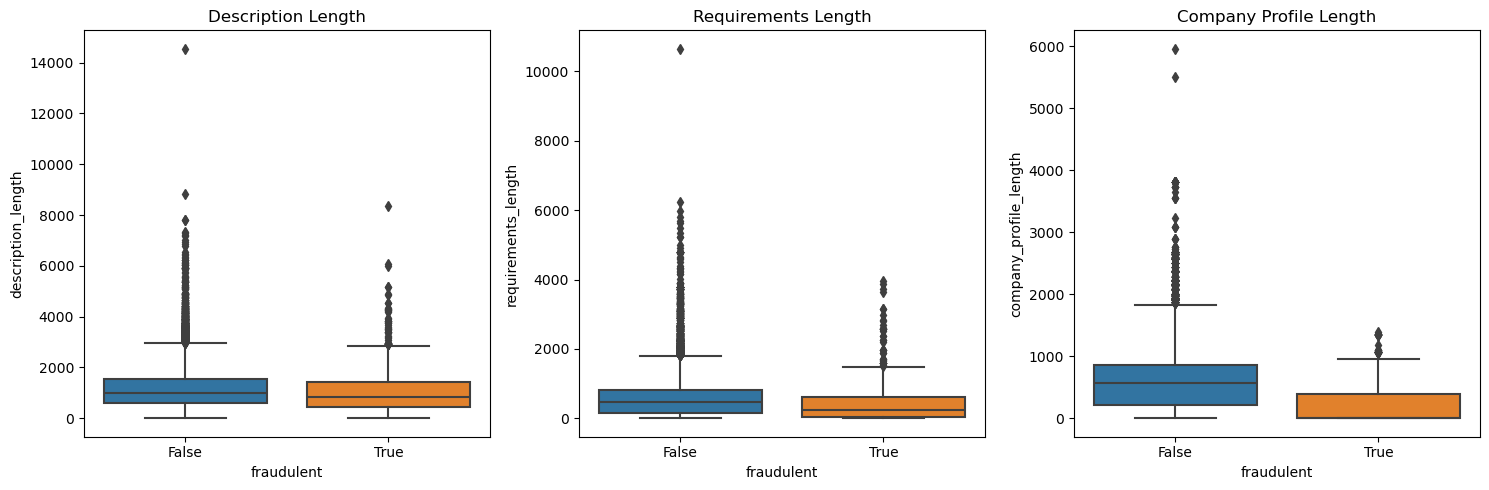

In [36]:
fig, axes = plt.subplots(1, 3, figsize=(15,5))

sns.boxplot(x='fraudulent', y='description_length', data=df, ax=axes[0])
axes[0].set_title('Description Length')

sns.boxplot(x='fraudulent', y='requirements_length', data=df, ax=axes[1])
axes[1].set_title('Requirements Length')

sns.boxplot(x='fraudulent', y='company_profile_length', data=df, ax=axes[2])
axes[2].set_title('Company Profile Length')

plt.tight_layout()
plt.show()

# Conclusion: low company profile length -> high indication of fraud 

### Finding 3: NA salary_range -> indication of anti-scam

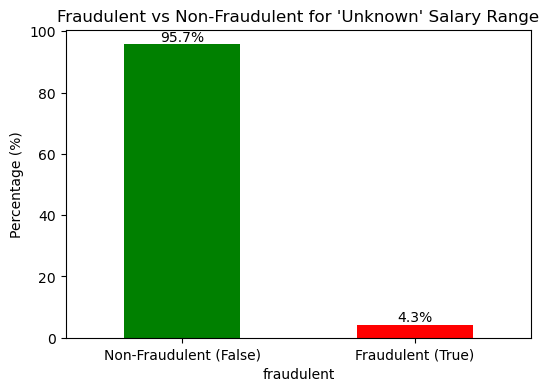

In [37]:
# Filter only 'Unknown' salary rows
unknown_salaries = df[df['salary_range'] == 'Unknown']

# Count fraudulent vs non-fraudulent
counts = unknown_salaries['fraudulent'].value_counts()

# Convert counts to percentages
percentages = counts / counts.sum() * 100

# Plot
plt.figure(figsize=(6,4))
percentages.plot(kind='bar', color=['green', 'red'])
plt.title("Fraudulent vs Non-Fraudulent for 'Unknown' Salary Range")
plt.ylabel("Percentage (%)")
plt.xticks(ticks=[0,1], labels=['Non-Fraudulent (False)', 'Fraudulent (True)'], rotation=0)
for i, v in enumerate(percentages):
    plt.text(i, v + 1, f"{v:.1f}%", ha='center')
plt.show()

### Finding 3.2 (Deeper dive): unrealistic salary range (e.g., max_salary too high or min_salary too low, large range) -> not indicative of scam/not scam

In [38]:
df["salary_range"].unique()

df[['min_salary', 'max_salary']] = df['salary_range'].str.extract(r'(\d+)-(\d+)')

# Convert to integers (will automatically convert NaN for 'Unknown')
df['min_salary'] = df['min_salary'].astype(float).astype('Int64')
df['max_salary'] = df['max_salary'].astype(float).astype('Int64')

df.head(10)

,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,...,industry,function,fraudulent,in_balanced_dataset,description_length,requirements_length,company_profile_length,missing_fields,min_salary,max_salary
0,Marketing Intern,"US, NY, New York",Marketing,Unknown,were food52 and weve created a groundbreaking ...,food52 a fastgrowing james beard awardwinning ...,experience with content management systems a ...,,False,True,...,NaN,Marketing,False,False,887,845,857,2,<NA>,<NA>
1,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,Unknown,90 seconds the worlds cloud video production s...,organised focused vibrant awesomedo you hav...,what we expect from you your key responsibilit...,what you will get from us through being part o...,False,True,...,Marketing and Advertising,Customer Service,False,False,2014,1409,1240,1,<NA>,<NA>
2,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,Unknown,valor services provides workforce solutions t...,our client located in houston is actively seek...,implement precommissioning and commissioning ...,,False,True,...,NaN,NaN,False,False,348,1351,862,6,<NA>,<NA>
3,Account Executive - Washington DC,"US, DC, Washington",Sales,Unknown,our passion for improving quality of life thro...,the company esri environmental systems resear...,educationbachelors or masters in gis busines...,our culture is anything but corporatewe have a...,False,True,...,Computer Software,Sales,False,False,2579,1421,595,0,<NA>,<NA>
4,Bill Review Manager,"US, FL, Fort Worth",NaN,Unknown,spotsource solutions llc is a global human cap...,job title itemization review manager location ...,qualifications rn license in the state of tex...,full benefits offered,False,True,...,Hospital & Health Care,Health Care Provider,False,False,1431,759,1589,1,<NA>,<NA>
5,Accounting Clerk,"US, MD,",NaN,Unknown,,job overview apex is an environmental consulti...,,,False,False,...,NaN,NaN,False,False,3359,0,0,6,<NA>,<NA>
6,Head of Content (m/f),"DE, BE, Berlin",ANDROIDPIT,20000-28000,founded in 2009 thefonpit agrose with its inte...,your responsibilities manage the englishspea...,your knowhow university or college degree i...,your benefits being part of a fastgrowing co...,False,True,...,Online Media,Management,False,False,433,601,852,0,20000,28000
7,Lead Guest Service Specialist,"US, CA, San Francisco",NaN,Unknown,airenvys mission is to provide lucrative yet h...,who is airenvy hey there we are seasoned entre...,experience with crm software live chat and ph...,competitive payyoull be able to eat steak ever...,False,True,...,NaN,NaN,False,False,2434,365,1003,6,<NA>,<NA>
8,HP BSM SME,"US, FL, Pensacola",NaN,Unknown,solutions3 is a womanowned small business whos...,implementationconfigurationtestingtraining o...,must be a us citizen an active tssci clearance...,,False,True,...,Information Technology and Services,NaN,False,False,74,345,1318,3,<NA>,<NA>
9,Customer Service Associate - Part Time,"US, AZ, Phoenix",NaN,Unknown,novitex enterprise solutions formerly pitney b...,the customer service associate will be based i...,minimum requirements minimum of 6 months cust...,,False,True,...,Financial Services,Customer Service,False,False,1210,775,669,1,<NA>,<NA>


In [39]:
df_numeric = df[df['salary_range'] != 'Unknown'].copy()
df_numeric['salary_diff'] = df_numeric['max_salary'] - df_numeric['min_salary']
# Define thresholds
high_salary_threshold = 1000000
big_diff_threshold = 500000
small_salary_threshold = 50

# Masks applied to the numeric-only dataframe
high_salary_mask = (df_numeric['min_salary'] >= high_salary_threshold) | (df_numeric['max_salary'] >= high_salary_threshold)
big_diff_mask = df_numeric['salary_diff'] >= big_diff_threshold
small_salary_mask = df_numeric['min_salary'] < small_salary_threshold

# Function to get counts
def fraud_counts(mask, description):
    subset = df_numeric[mask]
    counts = subset['fraudulent'].value_counts()
    return pd.Series({
        'Description': description,
        'Fraudulent_True': counts.get(True, 0),
        'Fraudulent_False': counts.get(False, 0),
        'Total': counts.sum()
    })

# Create table
table = pd.DataFrame([
    fraud_counts(high_salary_mask, f'High Salary >= {high_salary_threshold}'),
    fraud_counts(big_diff_mask, f'Salary Diff >= {big_diff_threshold}'),
    fraud_counts(small_salary_mask, f'Min Salary < {small_salary_threshold}')
])

print(table)

              Description  Fraudulent_True  Fraudulent_False  Total
0  High Salary >= 1000000               11                25     36
1   Salary Diff >= 500000               11                19     30
2         Min Salary < 50               33               283    316


### Finding 4: high count of null fills -> not indicative of scams

In [40]:
import pandas as pd

# Filter rows where missing_fields is not NaN
df_filtered = df[df['missing_fields'].notna()].copy()

# Group by missing_fields and fraudulent, count occurrences
missing_counts = df_filtered.groupby(['missing_fields', 'fraudulent']).size().unstack(fill_value=0)

# Add total and % fraudulent
missing_counts['Total'] = missing_counts.sum(axis=1)
missing_counts['% Fraudulent'] = missing_counts[True] / missing_counts['Total'] * 100

print(missing_counts.sort_index())

fraudulent      False  True  Total  % Fraudulent
missing_fields                                  
0                2974   207   3181      6.507388
1                5272   151   5423      2.784437
2                2140    83   2223      3.733693
3                1841   100   1941      5.151984
4                1301    77   1378      5.587808
5                1779   136   1915      7.101828
6                1535   100   1635      6.116208
7                 172    12    184      6.521739


### Finding 4: perhaps titles may be slightly different -> but benefits description, company profile, description, requirements etc are highly similar -> not definitive

In [41]:
# do tfidf and check for high sim score lead to fraud?
# Combine the relevant text fields into one column
df['combined_text'] = (
    df['description'].fillna('') + ' ' +
    df['department'].fillna('') + ' ' +
    df['salary_range'].fillna('') + ' ' +
    df['requirements'].fillna('') + ' ' +
    df['benefits'].fillna('')
)

In [42]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# TF-IDF vectorization
vectorizer = TfidfVectorizer(stop_words='english')
tfidf_matrix = vectorizer.fit_transform(df['combined_text'])

# Cosine similarity between all rows
cosine_sim = cosine_similarity(tfidf_matrix)

# We only need the upper triangle (no self-comparison)
upper_tri = np.triu(cosine_sim, k=1)

In [43]:
threshold = 0.98
high_sim_indices = np.argwhere(upper_tri >= threshold)

# Show pairs of listings with high similarity
similar_pairs = []
for i,j in high_sim_indices:
    similar_pairs.append({
        'Job1_index': i,
        'Job2_index': j,
        'Similarity': upper_tri[i,j],
        'Fraudulent_Job1': df.iloc[i]['fraudulent'],
        'Fraudulent_Job2': df.iloc[j]['fraudulent']
    })

similar_df = pd.DataFrame(similar_pairs)
print(similar_df)

        Job1_index  Job2_index  Similarity  Fraudulent_Job1  Fraudulent_Job2
0                0        4180    0.994049            False            False
1                0        4534    0.994460            False            False
2                3         149    1.000000            False            False
3                3         669    0.994404            False            False
4                3         726    0.994404            False            False
...            ...         ...         ...              ...              ...
100093       17784       17795    1.000000             True             True
100094       17790       17815    0.980534             True             True
100095       17791       17803    1.000000             True             True
100096       17797       17811    0.993048             True             True
100097       17802       17806    1.000000             True             True

[100098 rows x 5 columns]


In [44]:
# Count pairs where at least one job is fraudulent
high_fraud_pairs = similar_df[
    (similar_df['Fraudulent_Job1'] == True) | (similar_df['Fraudulent_Job2'] == True)
].shape[0]

# Total number of high similarity pairs
total_pairs = similar_df.shape[0]

# Percentage
percent_fraud = high_fraud_pairs / total_pairs * 100

print(f"Pairs with at least one fraudulent job: {high_fraud_pairs}/{total_pairs}")
print(f"Percentage: {percent_fraud:.2f}%")

Pairs with at least one fraudulent job: 1265/100098
Percentage: 1.26%


### Finding 5: Fraud Rates by Categorical Variables (e.g., Industry, Employment Type)

Top industries by fraud percentage:
                           count  Fraudulent_Count  Fraud_Percentage
industry                                                            
Ranching                       1                 1        100.000000
Military                       2                 1         50.000000
Animation                      5                 2         40.000000
Oil & Energy                 287               109         37.979094
Accounting                   159                57         35.849057
Leisure, Travel & Tourism     76                21         27.631579
Computer Networking           44                12         27.272727
Executive Office               8                 2         25.000000
Defense & Space                9                 2         22.222222
Investment Management          6                 1         16.666667


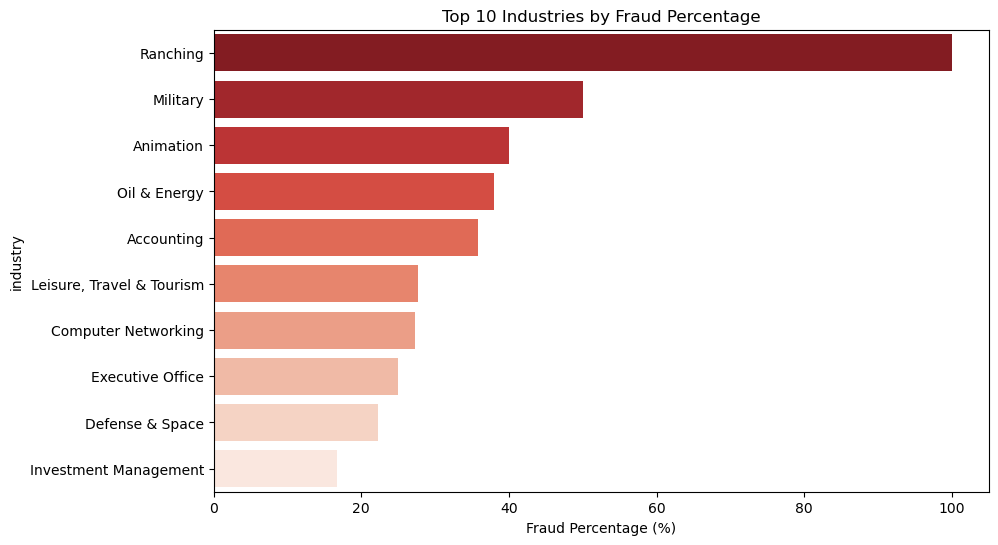

In [10]:
# Analyze fraud rates by industry
industry_fraud = df.groupby('industry')['fraudulent'].agg(['count', 'sum', lambda x: x.sum() / x.count() * 100]).rename(columns={'sum': 'Fraudulent_Count', '<lambda_0>': 'Fraud_Percentage'})
industry_fraud = industry_fraud.sort_values('Fraud_Percentage', ascending=False)
print("Top industries by fraud percentage:")
print(industry_fraud.head(10))

# Visualize
plt.figure(figsize=(10,6))
sns.barplot(data=industry_fraud.reset_index().head(10), x='Fraud_Percentage', y='industry', palette='Reds_r')
plt.title('Top 10 Industries by Fraud Percentage')
plt.xlabel('Fraud Percentage (%)')
plt.show()

Fraud rates by employment type:
                 count  Fraudulent_Count  Fraud_Percentage
employment_type                                           
Part-time          797                74          9.284818
Other              227                15          6.607930
Full-time        11620               490          4.216867
Contract          1524                44          2.887139
Temporary          241                 2          0.829876


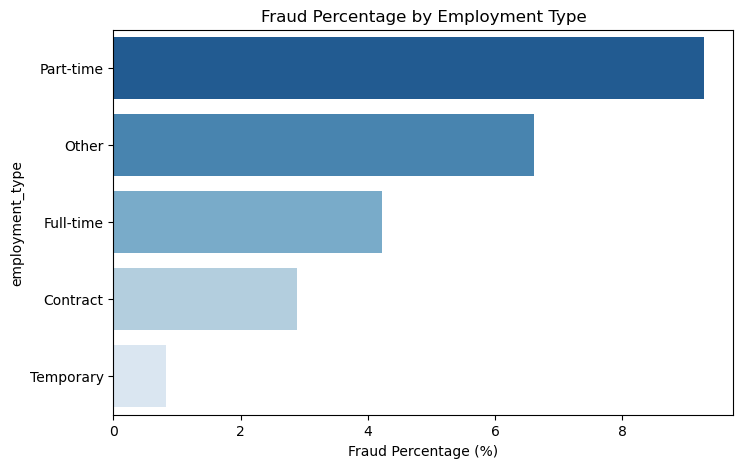

In [11]:
# Analyze fraud rates by employment_type
employment_fraud = df.groupby('employment_type')['fraudulent'].agg(['count', 'sum', lambda x: x.sum() / x.count() * 100]).rename(columns={'sum': 'Fraudulent_Count', '<lambda_0>': 'Fraud_Percentage'})
employment_fraud = employment_fraud.sort_values('Fraud_Percentage', ascending=False)
print("Fraud rates by employment type:")
print(employment_fraud)

# Visualize
plt.figure(figsize=(8,5))
sns.barplot(data=employment_fraud.reset_index(), x='Fraud_Percentage', y='employment_type', palette='Blues_r')
plt.title('Fraud Percentage by Employment Type')
plt.xlabel('Fraud Percentage (%)')
plt.show()

### Finding 6: Correlation Matrix for Numerical Features

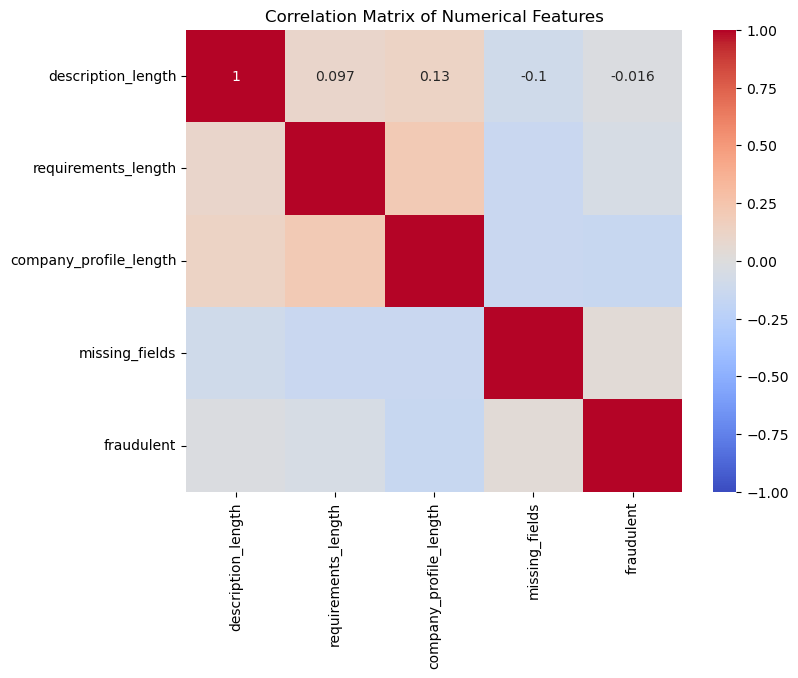

In [12]:
# Select numerical features for correlation
numerical_cols = ['description_length', 'requirements_length', 'company_profile_length', 'missing_fields', 'fraudulent']
corr_matrix = df[numerical_cols].corr()

# Plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix of Numerical Features')
plt.show()

# Key insights: Look for correlations with 'fraudulent' (e.g., negative with lengths)

### Finding 7: Top Keywords in Fraudulent vs Non-Fraudulent Descriptions

In [22]:
# Top TF-IDF features for fraudulent descriptions (unigrams, bigrams, trigrams)
fraudulent_descriptions = df[df['fraudulent'] == True]['benefits']
non_fraudulent_descriptions = df[df['fraudulent'] == False]['benefits']

# TF-IDF for fraudulent
tfidf_fraud = TfidfVectorizer(stop_words='english', max_features=30, ngram_range=(2,3))
tfidf_fraud_matrix = tfidf_fraud.fit_transform(fraudulent_descriptions)
fraud_features = tfidf_fraud.get_feature_names_out()
fraud_scores = tfidf_fraud_matrix.sum(axis=0).A1
fraud_top = sorted(zip(fraud_features, fraud_scores), key=lambda x: x[1], reverse=True)

# TF-IDF for non-fraudulent
tfidf_non_fraud = TfidfVectorizer(stop_words='english', max_features=30, ngram_range=(2,3))
tfidf_non_fraud_matrix = tfidf_non_fraud.fit_transform(non_fraudulent_descriptions)
non_fraud_features = tfidf_non_fraud.get_feature_names_out()
non_fraud_scores = tfidf_non_fraud_matrix.sum(axis=0).A1
non_fraud_top = sorted(zip(non_fraud_features, non_fraud_scores), key=lambda x: x[1], reverse=True)

print("Top n-grams in fraudulent benefits descriptions:")
for word, score in fraud_top[:15]:
    print(f"{word}: {score:.2f}")

print("\nTop n-grams in non-fraudulent benefits descriptions:")
for word, score in non_fraud_top[:15]:
    print(f"{word}: {score:.2f}")

# Insight: Fraudulent jobs may have more generic or vague benefits (e.g., "competitive salary", "health insurance") while non-fraudulent may have more specific perks.

Top n-grams in fraudulent benefits descriptions:
benefits package: 56.07
worklife balance: 54.53
working environment: 32.95
online training: 21.05
training provided: 10.32
positions available: 9.64
data entry: 9.27
start working: 9.27
training need: 9.27
entry level: 9.01
available started: 8.32
available started right: 8.32
data entry complete: 8.32
let opportunity: 8.32
let opportunity pass: 8.32

Top n-grams in non-fraudulent benefits descriptions:
competitive salary: 885.59
job description: 786.96
benefits package: 456.48
health dental: 409.01
work environment: 395.43
medical dental: 363.00
stock options: 360.84
dental vision: 358.02
health insurance: 356.13
offer competitive: 347.22
working environment: 312.15
life insurance: 272.92
competitive compensation: 241.87
paid time: 239.19
medical dental vision: 235.94


In [ ]:
# Top TF-IDF features for fraudulent descriptions (unigrams, bigrams, trigrams)
fraudulent_descriptions = df[df['fraudulent'] == True]['requirements']
non_fraudulent_descriptions = df[df['fraudulent'] == False]['requirements']

# TF-IDF for fraudulent
tfidf_fraud = TfidfVectorizer(stop_words='english', max_features=30, ngram_range=(2,3))
tfidf_fraud_matrix = tfidf_fraud.fit_transform(fraudulent_descriptions)
fraud_features = tfidf_fraud.get_feature_names_out()
fraud_scores = tfidf_fraud_matrix.sum(axis=0).A1
fraud_top = sorted(zip(fraud_features, fraud_scores), key=lambda x: x[1], reverse=True)

# TF-IDF for non-fraudulent
tfidf_non_fraud = TfidfVectorizer(stop_words='english', max_features=30, ngram_range=(2,3))
tfidf_non_fraud_matrix = tfidf_non_fraud.fit_transform(non_fraudulent_descriptions)
non_fraud_features = tfidf_non_fraud.get_feature_names_out()
non_fraud_scores = tfidf_non_fraud_matrix.sum(axis=0).A1
non_fraud_top = sorted(zip(non_fraud_features, non_fraud_scores), key=lambda x: x[1], reverse=True)

print("Top n-grams in fraudulent requirements descriptions:")
for word, score in fraud_top[:15]:
    print(f"{word}: {score:.2f}")

print("\nTop n-grams in non-fraudulent requirements descriptions:")
for word, score in non_fraud_top[:15]:
    print(f"{word}: {score:.2f}")

# Insight: Fraudulent jobs may have more emphasis on experience and soft skills (e.g., "communication", "teamwork") while non-fraudulent may have more technical requirements.

Top n-grams in fraudulent requirements descriptions:
communication skills: 51.01
customer service: 50.29
ability work: 48.52
years experience: 45.67
high school: 39.28
able work: 33.17
microsoft office: 33.03
school diploma: 32.57
bachelors degree: 32.13
skills ability: 31.94
experience working: 31.64
high school diploma: 31.19
experience required: 30.70
typing skills: 29.49
minimum years: 27.98

Top n-grams in non-fraudulent requirements descriptions:
communication skills: 1473.52
years experience: 1404.73
ability work: 882.74
experience working: 824.00
customer service: 794.90
bachelors degree: 723.19
skills ability: 706.23
experience preferred: 670.08
computer science: 642.23
minimum years: 600.95
university degree: 594.86
track record: 549.39
verbal written: 537.34
skills experience: 516.47
written verbal: 516.02


In [ ]:
# Top TF-IDF features for fraudulent descriptions (unigrams, bigrams, trigrams)
fraudulent_descriptions = df[df['fraudulent'] == True]['company_profile']
non_fraudulent_descriptions = df[df['fraudulent'] == False]['company_profile']

# TF-IDF for fraudulent
tfidf_fraud = TfidfVectorizer(stop_words='english', max_features=30, ngram_range=(2,3))
tfidf_fraud_matrix = tfidf_fraud.fit_transform(fraudulent_descriptions)
fraud_features = tfidf_fraud.get_feature_names_out()
fraud_scores = tfidf_fraud_matrix.sum(axis=0).A1
fraud_top = sorted(zip(fraud_features, fraud_scores), key=lambda x: x[1], reverse=True)

# TF-IDF for non-fraudulent
tfidf_non_fraud = TfidfVectorizer(stop_words='english', max_features=30, ngram_range=(2,3))
tfidf_non_fraud_matrix = tfidf_non_fraud.fit_transform(non_fraudulent_descriptions)
non_fraud_features = tfidf_non_fraud.get_feature_names_out()
non_fraud_scores = tfidf_non_fraud_matrix.sum(axis=0).A1
non_fraud_top = sorted(zip(non_fraud_features, non_fraud_scores), key=lambda x: x[1], reverse=True)

print("Top n-grams in fraudulent company profile descriptions:")
for word, score in fraud_top[:15]:
    print(f"{word}: {score:.2f}")

print("\nTop n-grams in non-fraudulent company profile descriptions:")
for word, score in non_fraud_top[:15]:
    print(f"{word}: {score:.2f}")

# Insight: Fraudulent jobs may have more emphasis on hiring process.

Top n-grams in fraudulent company profile descriptions:
refined resources: 22.62
aptitude staffing: 22.39
real estate: 21.00
aptitude staffing solutions: 16.90
staffing solutions: 16.90
help develop: 15.49
hiring process: 15.49
hiring process provide: 15.49
signing bonus: 15.45
candidates enjoy: 12.62
employees receive: 12.62
access anyperk: 9.83
bonus program: 9.83
candidates encouraged: 9.83
candidates encouraged participate: 9.83

Top n-grams in non-fraudulent company profile descriptions:
new york: 701.73
high quality: 402.22
customer satisfaction: 388.36
increase productivity: 377.34
document communications: 367.93
solutions help: 298.84
help teachers: 242.00
help teachers safe: 242.00
jobs abroad: 242.00
safe secure: 242.00
safe secure jobs: 242.00
secure jobs: 242.00
secure jobs abroad: 242.00
teachers safe: 242.00
teachers safe secure: 242.00
